## 1. Import Required Libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import MinMaxScaler

from keras.models import Sequential
from keras.layers import LSTM,Dense,Dropout
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from keras.optimizers import Adam

plt.style.use("seaborn-v0_8")

## Step 1. Load Cleaned Data

In [12]:
tsla = pd.read_csv(
    "../data/processed/TSLA_cleaned.csv",
    #header=[0,1],      # because yfinance created MultiIndex columns
    index_col=0,
    parse_dates=True
)

tsla.head()

,Adj Close,Close,High,Low,Open,Volume,Ticker,Daily Return,Rolling Mean,Rolling Std
Date,,,,,,,,,,
2015-01-02,14.620667,14.620667,14.883333,14.217333,14.858000,71466000,TSLA,NaN,NaN,NaN
2015-01-05,14.006000,14.006000,14.433333,13.810667,14.303333,80527500,TSLA,-0.042041,NaN,NaN
2015-01-06,14.085333,14.085333,14.280000,13.614000,14.004000,93928500,TSLA,0.005664,NaN,NaN
2015-01-07,14.063333,14.063333,14.318667,13.985333,14.223333,44526000,TSLA,-0.001562,NaN,NaN
2015-01-08,14.041333,14.041333,14.253333,14.000667,14.187333,51637500,TSLA,-0.001564,NaN,NaN


## Step 2. Train/Test Split

In [13]:
print(tsla.index)

DatetimeIndex(['2015-01-02', '2015-01-05', '2015-01-06', '2015-01-07',
               '2015-01-08', '2015-01-09', '2015-01-12', '2015-01-13',
               '2015-01-14', '2015-01-15',
               ...
               '2026-06-15', '2026-06-16', '2026-06-17', '2026-06-18',
               '2026-06-22', '2026-06-23', '2026-06-24', '2026-06-25',
               '2026-06-26', '2026-06-29'],
              dtype='datetime64[ns]', name='Date', length=2888, freq=None)


In [14]:
train = tsla.loc["2015":"2024"]
test = tsla.loc["2025":"2026"]

train_series = train["Adj Close"]
test_series = test["Adj Close"]

## Step 3. ARIMA Model

### 3.1 Check ACF/PACF

In [15]:
model = auto_arima(
    train_series,
    seasonal=False,
    trace=True,
    suppress_warnings=True
)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=16374.056, Time=6.02 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.19 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.54 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.57 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.07 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.99 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 8.421 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2516
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8183.054
Date:                Sun, 05 Jul 2026   AIC                          16368.109
Time:                        01:06:15   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
    

### 3.2 Train ARIMA

In [16]:
arima = ARIMA(
    train_series,
    order=(2,1,2)
)

arima_fit = arima.fit()

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregres

### 3.3 Forecast

In [17]:
forecast = arima_fit.forecast(
    steps=len(test)
)

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


### Evaluate the Model

In [18]:
mae = mean_absolute_error(test_series,forecast)

rmse = np.sqrt(
    mean_squared_error(test_series,forecast)
)

mape = mean_absolute_percentage_error(
    test_series,
    forecast
)

print(mae,rmse,mape)

53.91711642418598 69.39703157883582 0.16997036948986932


## Step 4. LSTM

In [19]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(
    train_series.values.reshape(-1,1)
)

test_scaled = scaler.transform(
    test_series.values.reshape(-1,1)
)

### Create Sequences

In [20]:
window = 60

X_train = []
y_train = []

for i in range(window, len(train_scaled)):
    X_train.append(train_scaled[i-window:i])
    y_train.append(train_scaled[i])

X_train = np.array(X_train)
y_train = np.array(y_train)

print(X_train.shape)
print(y_train.shape)

(2456, 60, 1)
(2456, 1)


### Create Testing Sequences

In [21]:
combined = pd.concat([train_series, test_series])

inputs = combined[len(combined) - len(test) - window:]

inputs = scaler.transform(
    inputs.values.reshape(-1,1)
)

X_test = []
y_test = test_series.values

for i in range(window, len(inputs)):
    X_test.append(inputs[i-window:i])

X_test = np.array(X_test)

print(X_test.shape)

(372, 60, 1)


### Build LSTM

In [25]:
model = Sequential()

model.add(
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(window,1)
    )
)

model.add(Dropout(0.2))

model.add(
    LSTM(
        units=32
    )
)

model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mean_squared_error"
)

model.summary()

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

### Train

In [26]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - loss: 0.0086 - val_loss: 0.0027
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - loss: 0.0021 - val_loss: 0.0027
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 0.0018 - val_loss: 0.0022
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 0.0017 - val_loss: 0.0027
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - loss: 0.0017 - val_loss: 0.0022
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 0.0017 - val_loss: 0.0027
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 0.0016 - val_loss: 0.0023
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 0.0014 - val_loss: 0.0046
Epoch 9/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 0.0014 - val_loss: 0.0017
Epoch 10/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - loss: 0.0014 - val_loss: 0.0022
Epoch 11/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 0.0013 - val_loss: 0.0020
Epoch 12/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - loss: 0.

### Predict

In [27]:
predictions = model.predict(X_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 135ms/step


### Convert Back to Original Prices

In [28]:
predictions = scaler.inverse_transform(predictions)

predictions = predictions.flatten()

### Evaluate the Model

In [29]:
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

mape = mean_absolute_percentage_error(
    y_test,
    predictions
)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.4f}")

MAE : 23.88
RMSE: 28.21
MAPE: 0.0627


### Visualize Predictions

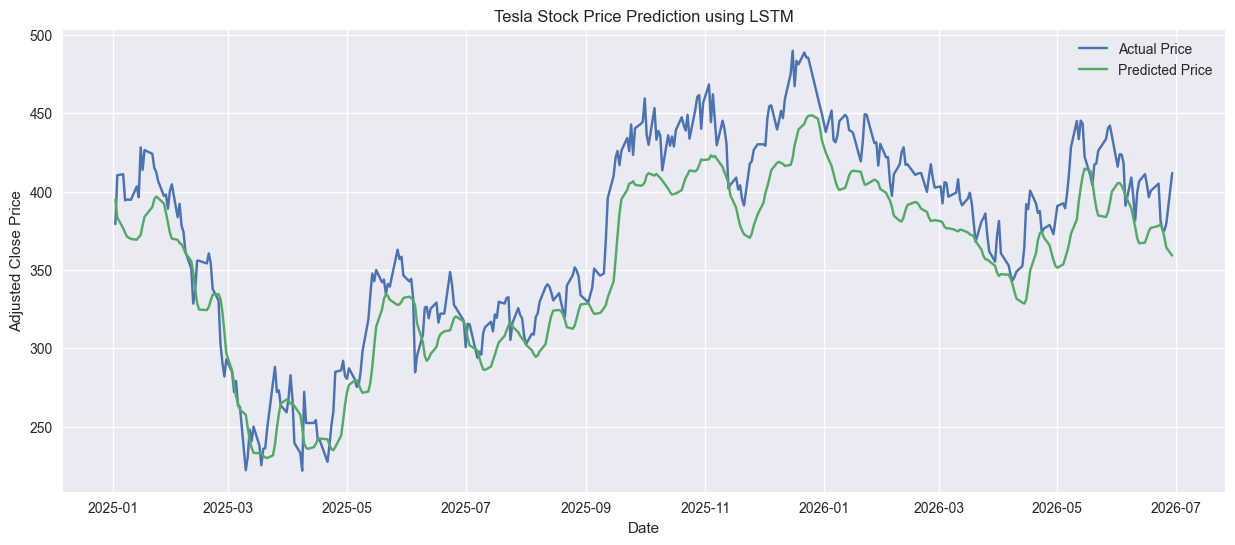

In [30]:
plt.figure(figsize=(15,6))

plt.plot(
    test.index,
    y_test,
    label="Actual Price"
)

plt.plot(
    test.index,
    predictions,
    label="Predicted Price"
)

plt.title("Tesla Stock Price Prediction using LSTM")

plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")

plt.legend()

plt.show()

### Plot Training Loss

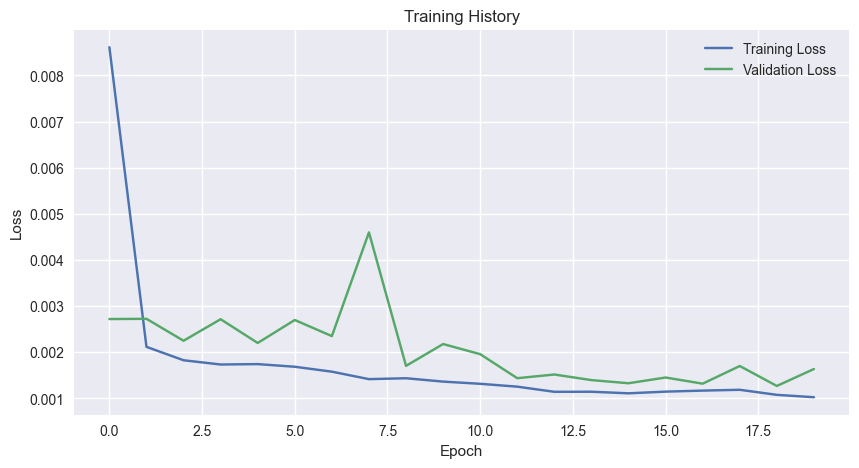

In [31]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training History")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

## Step 5. Hyperparameter Optimization

In [32]:
experiments = [
    {
        "layers": 1,
        "units": 32,
        "epochs": 20,
        "batch": 32,
        "lr": 0.001
    },
    {
        "layers": 2,
        "units": 64,
        "epochs": 20,
        "batch": 32,
        "lr": 0.001
    },
    {
        "layers": 2,
        "units": 128,
        "epochs": 30,
        "batch": 64,
        "lr": 0.0005
    }
]